## Tools工具的概述

![image.png](img.png)

在LangChain中，工具（Tools）实际上是指明确定义了输入和输出的 可调用函数 。因此， 工具调用(Tool Calling) 也被称为 函数调用(Function Calling) 。

### 1. 直接调用 （测试用，实际项目里不采用）
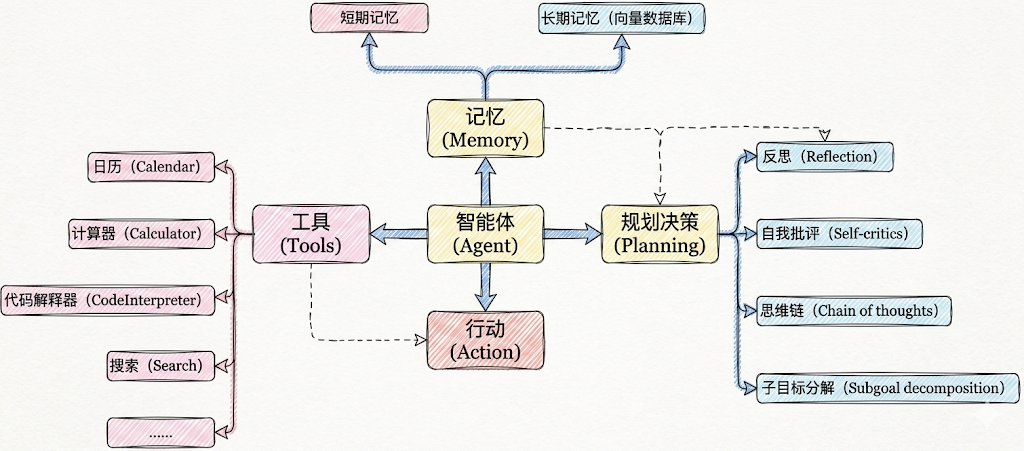

In [1]:
from langchain_core.messages import ToolMessage
from langchain_core.tools import tool

@tool
def get_weather(city: str) -> str:
    """
    获取指定城市的的天气信息

    Args:
        city: 城市名称，如北京、上海

    Returns:
        天气信息字符串

    """
    return city + "晴天，温度 15°C"

# 使用 invoke()方法调用.再实际工程项目里不推荐，只是为了测试工具类而已
result = get_weather.invoke({"city": "北京"})

print(result)


北京晴天，温度 15°C


### 2. 绑定到模型（主流）

In [5]:
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
from dotenv import load_dotenv
import os

#优先加载配置
load_dotenv(override=True)

model_openai = init_chat_model(
    model="qwen3.7-flash",
    model_provider="openai",
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL"),
)

@tool
def get_weather(city: str) -> str:
    """
    获取指定城市的的天气信息

    Args:
        city: 城市名称，如北京、上海

    Returns:
        天气信息字符串

    """
    return  f"{city}晴天，温度 15°C"


#绑定工具
model_with_tools = model_openai.bind_tools([get_weather])

response = model_with_tools.invoke("北京天气如何？")

t_calls = response.tool_calls

for t_call in t_calls:
    if t_call["name"] == "get_weather":
        #返回的是ToolMessage
        t_response = get_weather.invoke(t_call)
        print(type(t_response))
        print(t_response.content)

<class 'langchain_core.messages.tool.ToolMessage'>
北京晴天，温度 15°C


### 3.工具调用的整体流程

大模型能根据对话上下文决定何时调用工具以及传递哪些参数。

经典流程如下：

![image.png](img_1.png)